# HT-CapsNet Current-Run Trade-Off Plots

Run matrix: the paper-baseline HT-CapsNet port, coarse-first explicit
lexicographic training, and HCC with `step@0` or `step@160` (80% of the upstream
200-epoch horizon, matching the relative timing used for HRN). Arms whose runs
have not completed appear in the availability listing as missing and are simply
absent from the figures.

## Read the margin-collapse check before interpreting anything here

HT-CapsNet has a degenerate attractor: capsule lengths go constant and the model
emits the class prior. A collapsed seed still produces a complete
`test_metrics.yaml`, so it will be aggregated here alongside healthy seeds and
will drag the mean down while inflating the standard deviation.

Detection, from `run_log.jsonl` rather than from this notebook: the per-level
margin loss parks at the closed-form constant-output minimum
`loss*(C) = (m+ - c)^2 + lambda (C-1)(c - m-)^2` with
`c = (m+ + lambda (C-1) m-) / (1 + lambda (C-1))`. For `m+=0.9`, `m-=0.1`,
`lambda=0.5`: C=200 -> 0.6336, C=100 -> 0.6273, C=70 -> 0.6220, C=38 -> 0.6072,
C=13 -> 0.5486. Confirm with accuracy pinned at the majority-class share and
`delta_param_norm_t1` dropping to about 1 where healthy seeds sit at 25-35. As of
2026-08-05 every Aircraft seed had collapsed and CUB-200 collapsed in roughly one
run out of three.

Check the per-seed spread in the summary table below against that before
reporting an HT-CapsNet mean.

## Other fidelity caveats

- Local seeds are 0/1/2; upstream uses 42 by default and 101/202/303 in
  `run_seeds.sh`, so nothing here is seed-matched to published numbers.
- The local configs use `lr_decay_rate=0.95` where the pinned upstream source
  uses 0.9, and upstream enables EarlyStopping with `restore_best_weights` while
  the local trainer has none.
- Aircraft is a local extrapolation; the port is TensorFlow-to-PyTorch.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points, bars, and error bars are mean +/- sample standard
deviation across training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Every figure and table below reads the **independently selected** checkpoint and
the independent metric family. Top-down decoding is deliberately not offered:
its predicted path is consistent by construction, so `tice_topdown` is exactly
`0.0` in all 194 completed seed directories under `/scratch/g.saggini1/outputs`
(checked 2026-08-05) and `fpa_topdown` equals top-down fine accuracy exactly,
which leaves a top-down trade-off view with nothing to show.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

One dataset per row rather than three panels side by side: at 6.3 in a 1x3 row
leaves about 2 in per panel, which is not enough for the direct labels or for
grouped bars once a run matrix grows.

In [8]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    MECHANISM_COLORS,
    VARIANT_MARKERS,
    check_encoding,
    discover_rows,
    encode_rows,
    model_reference_specs,
    plot_level_accuracy,
    plot_level_accuracy_deltas,
    plot_tradeoff,
    print_availability,
    print_reference_availability,
    print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'ht_capsnet'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

In [9]:
RUN_SPECS = [
    {'key': 'baseline', 'label': 'Baseline',
     'mechanism': 'baseline', 'variant': 'native', 'canonical': True,
     'run_name': 'capsnet_{dataset}'},
    {'key': 'lex_coarse_first', 'label': 'Lex coarse-first',
     'mechanism': 'lex', 'variant': 'coarse_first',
     'run_name': 'ht_capsnet_{dataset}_lex_coarse_first'},
    {'key': 'hcc_step_0', 'label': 'HCC step@0',
     'mechanism': 'hcc', 'variant': 'immediate',
     'run_name': 'capsnet_hcc_{dataset}_step_0epoch'},
    {'key': 'hcc_step_160', 'label': 'HCC step@160',
     'mechanism': 'hcc', 'variant': 'delayed',
     'run_name': 'capsnet_hcc_{dataset}_step_160epoch'},
]

REFERENCE_SPECS = model_reference_specs(exclude={'ht_capsnet'})

In [10]:
rows, missing_runs = discover_rows(OUTPUTS_ROOT, DATASETS, RUN_SPECS)
reference_rows, missing_references = discover_rows(
    OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS, pareto=False
)

# Colour encodes the mechanism and means the same thing in every model's
# notebook; shape separates the variants within a mechanism.
ENCODING = encode_rows(
    rows,
    hue=('mechanism', MECHANISM_COLORS),
    shape=('variant', VARIANT_MARKERS),
)

print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_references, DATASETS)
check_encoding(rows, reference_rows, DATASETS)


CIFAR-100 runs
  Baseline                   missing: capsnet_cifar100
  Lex coarse-first           missing: ht_capsnet_cifar100_lex_coarse_first
  HCC step@0                 missing: capsnet_hcc_cifar100_step_0epoch
  HCC step@160               missing: capsnet_hcc_cifar100_step_160epoch

CUB-200 runs
  Baseline                    3 seed(s): capsnet_cub200
  Lex coarse-first           missing: ht_capsnet_cub200_lex_coarse_first
  HCC step@0                 missing: capsnet_hcc_cub200_step_0epoch
  HCC step@160               missing: capsnet_hcc_cub200_step_160epoch

Aircraft runs
  Baseline                    3 seed(s): capsnet_aircraft
  Lex coarse-first           missing: ht_capsnet_aircraft_lex_coarse_first
  HCC step@0                 missing: capsnet_hcc_aircraft_step_0epoch
  HCC step@160               missing: capsnet_hcc_aircraft_step_160epoch

CIFAR-100 reference models
  H-CAST          3 seed(s)  FPA 73.48% ± 0.19      TICE 7.61% ± 0.29
  HRN             3 seed(s)  FPA 71.6

[]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, a
one-standard-deviation covariance ellipse when at least three seeds are
available, and a thin crosshair through the canonical baseline so every other
run reads as above/below and left/right of it.

Cross-model references (the other four model families) use the off-scale
representation: the axis range is frozen on the HT-CapsNet runs alone, and a
reference outside that range is pinned into a shaded gutter, keeping its own
marker shape and gaining a small arrow that points toward the true value. Its
label reports the actual numbers, because the pinned position deliberately is
not one. When a dataset panel holds fewer than two HT-CapsNet runs there is no
range to freeze on, so that panel falls back to a single shared scale.

Reference models were trained with their own recipes and epoch budgets. They are
context for the achievable operating region, not weight-matched or
schedule-matched comparisons, and they are excluded from the Pareto analysis.

The lex arm sets `model.loss.weight_mode=none` (unit per-level margin weights)
while the baseline uses `dynamic`, so a lex-versus-baseline gap mixes the
gradient projection with a level-weighting change.

### Point encoding

Colour encodes the **mechanism** — the intervention a run applies — and means
the same thing in every model's notebook: blue is the native baseline,
vermillion lexicographic gradient projection, green the HCC output constraint.
Marker shape separates variants within a mechanism, so HCC `step@0` is a green
square and the delayed arm a green diamond here and everywhere else.
Cross-model references give up colour entirely and are drawn in neutral grey,
told apart by shape, so the focal family owns the colour dimension. The bar
figures below use the same scheme with hatch standing in for marker shape.

Direct labels follow `point_labels='off_scale'`: only gutter-pinned references
are labelled, because their drawn position is deliberately false and the label
is the only record of the true value. Everything else is identified by the
legend, which is a complete key, and sits at a truthful position. A panel that
does not freeze therefore carries no direct labels at all; read its values off
the axes, or from the availability and summary tables.

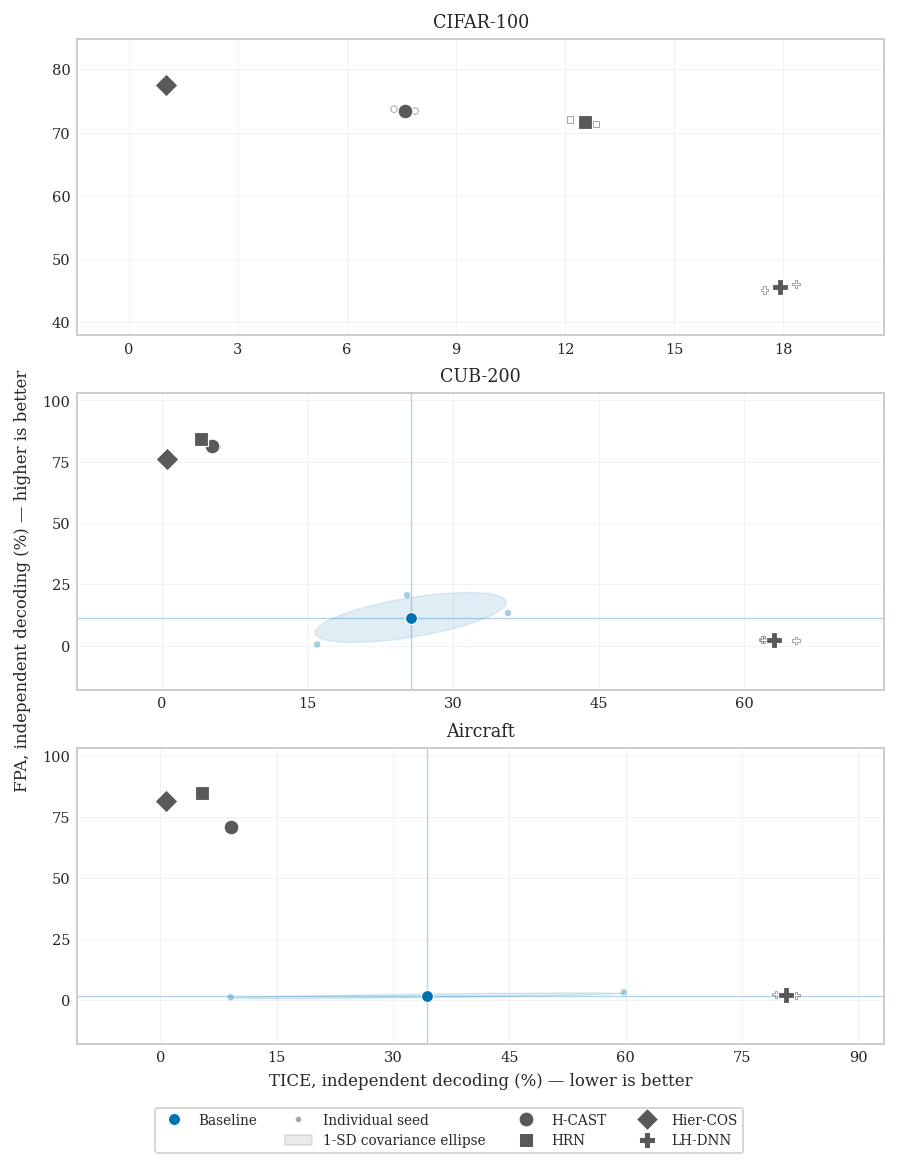

In [11]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
    encoding=ENCODING,
)

## Accuracy Per Hierarchy Level

Absolute coarse, middle, and fine accuracy for each run of this model family.

Cross-model references are deliberately left out. They were trained with their
own recipes and epoch budgets, so a bar beside them invites a controlled reading
the data does not support; the trade-off figure above already places them, and
the availability and summary tables carry their exact numbers. Dropping them
also keeps the bars wide enough to stay readable as the run matrix grows.

This is the figure where margin collapse is easiest to spot: a collapsed seed
pins each level at its majority-class share, which shows up as a level profile
that is flat in the wrong place with a large error bar.

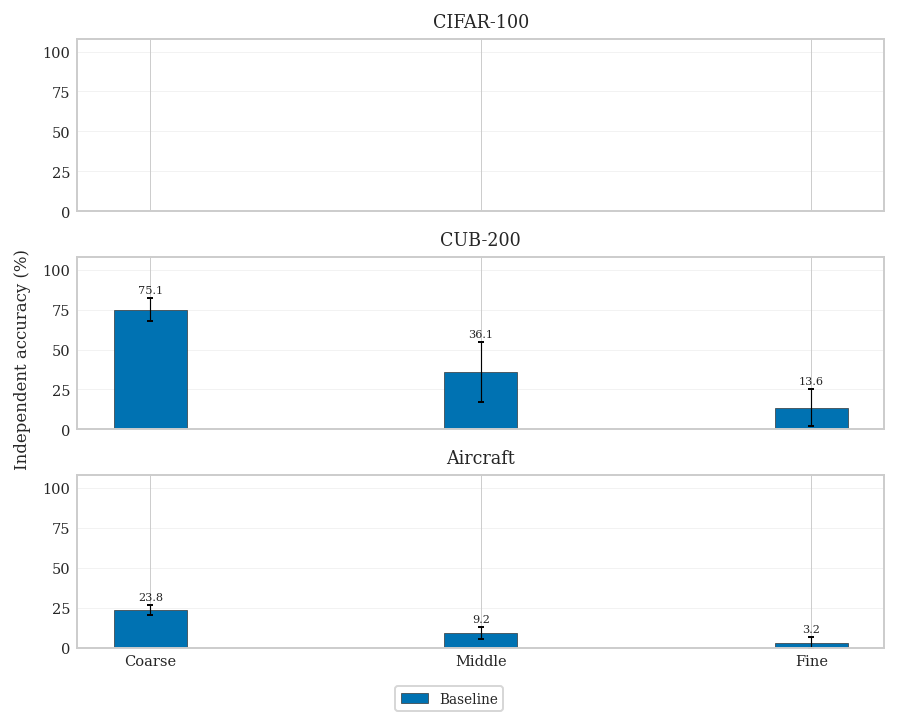

In [12]:
plot_level_accuracy(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
)

## Selected-Run Effects Across Hierarchy Levels

Bars are matched-seed changes in coarse, middle, and fine accuracy from the
HT-CapsNet baseline, in percentage points. Only seeds present in both the run and
the baseline contribute. Each panel has its own vertical scale, because delta
ranges differ by an order of magnitude across datasets; read the printed values,
not the relative bar heights, when comparing datasets. A collapsed baseline seed makes the corresponding delta
meaningless in both directions, so confirm seed health before reading these bars.

In [13]:
plot_level_accuracy_deltas(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    baseline_name='the HT-CapsNet baseline',
)

No run/baseline pair available for the delta figure.


## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no other run of the same model
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. Reference models are not part of this comparison. AHD and
weighted AP are reported as additional columns but do not enter the Pareto test.

In [14]:
print_summary(rows, DATASETS)


CIFAR-100
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status

CUB-200
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status
  Baseline                  3  94.3 ± 85.7     11.46% ± 10.18    25.65% ± 9.83     1.788 ± 0.349     20.21% ± 12.57    Pareto-optimal

Aircraft
  run                       n  epoch           FPA               TICE              AHD               weighted AP       status
  Baseline                  3  85.3 ± 86.4     1.56% ± 1.23      34.42% ± 25.35    2.666 ± 0.065     8.39% ± 3.57      Pareto-optimal
